# 线性神经网络

## 矢量化加速

**⽮量化代码通常会带来数量级的加速。**

In [3]:
%matplotlib inline
import math
import time
import numpy as np
import torch

In [7]:
class Timer:
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [ ]:
n = 10000
a = torch.ones([n])
b = torch.ones([n])

c = torch.zeros([n])

'0.06429 sec'

In [9]:
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]

f'{timer.stop():.5f} sec'

'0.06293 sec'

In [10]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00010 sec'

## 正态分布与平方损失

**均⽅误差损失函数（简称均⽅损失）可以⽤于线性回归**

In [13]:
import matplotlib.pyplot as plt

In [14]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

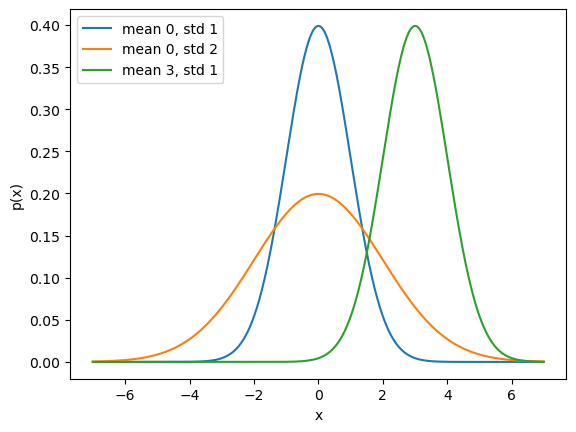

In [17]:
x = np.arange(-7, 7, 0.01)

# 均值和标准差对
params = [(0, 1), (0, 2), (3, 1)]
[plt.plot(x, normal(x, mu, sigma), label=f'mean {mu}, std {sigma}') for mu, sigma in params]

plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend()
plt.show()

## 线性回归的从零开始实现

In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

### 生成数据集

In [2]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)
print('features:', features[0], '\nlabel:', labels[0])

features: tensor([-0.0148,  0.6366]) 
label: tensor([2.0161])


Text(0, 0.5, 'label')

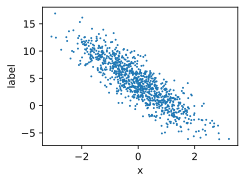

In [3]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1)
d2l.plt.xlabel('x')
d2l.plt.ylabel('label')

### 读取训练集

In [4]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i + batch_size, num_examples)])

        yield features[batch_indices], labels[batch_indices]

In [5]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 1.8403, -1.2094],
        [-0.7109,  1.2311],
        [-0.1227, -0.4929],
        [ 0.0659, -0.5380],
        [ 0.2410,  0.8733],
        [ 1.2857,  0.8129],
        [ 0.7304,  1.3294],
        [ 1.4775, -0.5641],
        [ 0.6313,  2.5487],
        [ 0.1526, -0.0591]]) 
 tensor([[11.9808],
        [-1.4149],
        [ 5.6274],
        [ 6.1407],
        [ 1.6994],
        [ 3.9977],
        [ 1.1412],
        [ 9.0689],
        [-3.2017],
        [ 4.6996]])


### 初始化模型

In [15]:
# 初始化模型参数
w = torch.zeros(2, 1, requires_grad=True)# torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.03
num_epochs = 3
net = d2l.linreg
loss = d2l.squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y) # X和y的小批量损失
        # 因为l形状是(batch_size, 1)，而不是一个标量。l中的所有元素被加到一起
        # 并以此计算[w, b]的梯度
        l.sum().backward()
        d2l.sgd([w, b], lr, batch_size)

    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.028182
epoch 2, loss 0.000103
epoch 3, loss 0.000051


In [17]:
print(w)
print(b)
print(f'w的误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的误差: {true_b - b}')

tensor([[ 1.9989],
        [-3.4007]], requires_grad=True)
tensor([4.1995], requires_grad=True)
w的误差: tensor([0.0011, 0.0007], grad_fn=<SubBackward0>)
b的误差: tensor([0.0005], grad_fn=<RsubBackward1>)


## 线性回归的简洁实现

In [4]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

### 生成数据集

In [5]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

### 读取数据集

In [6]:
batch_size = 10
data_iter = d2l.load_array((features, labels), batch_size)

In [7]:
next(iter(data_iter))

[tensor([[-0.5747, -1.3122],
         [ 1.9251,  1.6347],
         [-0.6737, -0.2423],
         [ 0.4525, -0.9113],
         [ 1.3640,  0.8331],
         [ 0.3079,  0.2963],
         [ 0.4102,  0.9417],
         [-0.1487, -0.5558],
         [-0.9980, -0.4604],
         [-1.8276,  1.4791]]),
 tensor([[ 7.4946],
         [ 2.4911],
         [ 3.6877],
         [ 8.2219],
         [ 4.0715],
         [ 3.8073],
         [ 1.8253],
         [ 5.8009],
         [ 3.7753],
         [-4.4836]])]

### 定义模型

In [8]:
from torch import nn

net = nn.Sequential(nn.Linear(2, 1))

In [9]:
# 初始化模型参数
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [10]:
loss = nn.MSELoss()

In [ ]:
# 当我们实例化⼀个SGD实例时，我们要指定优化的参数（可通过net.parameters()从我们的模型中获得）
# 以及优化算法所需的超参数字典。
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

In [13]:
num_epochs = 3
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()

    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

epoch 1, loss 0.000221
epoch 2, loss 0.000107
epoch 3, loss 0.000107


In [15]:
w = net[0].weight.data
print('w的估计误差: ', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差: ', true_b - b)

w的估计误差:  tensor([-0.0004, -0.0002])
b的估计误差:  tensor([-0.0006])


## Softmax

**适用于分类问题**

**⾸先对每个未规范化的预测求幂，这样可以确保输出⾮负。\
为了确保最终输出的概率值总和为1，我们再让每个求幂后的结果除以它们的总和。**

$\pmb{\hat{y}} = softmax(\pmb{o}) \quad 其中 \quad \hat{y_i} = \frac{exp(o_j)}{\sum_k{exp(o_k)}}$

**对数似然**

softmax函数给出了⼀个向量\pmb{\hat{y}}，我们可以将其视为“对给定任意输⼊x的每个类的条件概率”。例如，$\hat{y_1}=P(y =
猫 | x)。$
假设整个数据集{X, Y}具有n个样本，其中索引i的样本由特征向量x_(i)和独热标签向量y_(i)组成。
我们可以将估计值与实际值进⾏⽐较：
$$P\left (\pmb{Y} | \pmb{X} \right) = \prod_{i=1}^n P\left(\pmb{y}^{(i)}|\pmb{x}^{(i)}\right)$$

**softmax梯度是观测值y和估计值yˆ之间的差异**

交叉熵损失:
$$l(\pmb{y}, \pmb{\hat{y}})=-\sum_{j=1}^1 y_jlog\hat{y_j}$$

## 图像分类数据集

In [30]:
%matplotlib inline
import torch
import torch.nn as nn
import torchvision
from torch.utils import data
from d2l import torch as d2l

d2l.use_svg_display()

### 读取数据集

In [3]:
# 通过ToTensor实例将图像数据从PIL类型变换成32位浮点数格式，
# 并除以255使得所有像素的数值均在0~1之间
trans = torchvision.transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(root='../data', train=True,transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(root='../data', train=False, transform=trans, download=True)


100.0%
100.0%
100.0%
100.0%


In [4]:
len(mnist_train), len(mnist_test)

(60000, 10000)

In [5]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

array([<Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 't-shirt'}>], dtype=object)

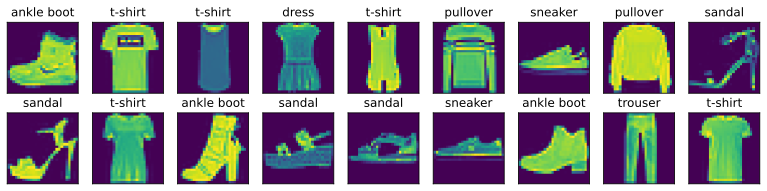

In [6]:
X, y = next(iter(data.DataLoader(mnist_train, batch_size = 18)))
d2l.show_images(X.reshape(18, 28, 28), 2, 9, titles=d2l.get_fashion_mnist_labels(y))

### 读取小批量

In [7]:
batch_size = 256

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True)

In [8]:
timer = d2l.Timer()
for X, y in train_iter:
    continue
f'{timer.stop():.2f} sec'

'5.45 sec'

### 整合所有组件

In [9]:
train_iter, test_iter = d2l.load_data_fashion_mnist(32, resize=64)
for X, y in train_iter:
    print(X.shape, X.dtype, y.shape, y.dtype)
    break

torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64


## softmax回归的从零开始实现

In [ ]:
import torch
from IPython import display
from d2l import torch as d2l

In [11]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

### 初始化模型参数

In [12]:
num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

### 定义softmax操作

In [13]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(-1, keepdim=True)
    return X_exp / partition

In [14]:
X = torch.normal(0, 1, (2, 5))
X_prob = softmax(X)
X_prob, X_prob.sum(1)

(tensor([[0.1360, 0.0685, 0.2415, 0.5165, 0.0375],
         [0.1597, 0.3360, 0.2468, 0.1081, 0.1495]]),
 tensor([1.0000, 1.0000]))

### 定义模型

In [15]:
def net(X):
    return softmax(torch.matmul(X.reshape(-1, W.shape[0]), W) + b)

### 定义损失函数

In [18]:
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0,1], y]

tensor([0.1000, 0.5000])

In [19]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y])

cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

In [25]:
def accuracy(y_hat, y):
    if(len(y_hat.shape) > 1 and y_hat.shape[1] > 1):
        y_hat = y_hat.argmax(axis=1)

    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

accuracy(y_hat, y) / len(y)

0.5

In [34]:
class Accumulator:
    def __init__(self, n):
        self.data = [0.0] *n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [35]:
def evaluate_accuracy(net, data_iter):
    if(isinstance(net, nn.Module)):
        net.eval()

    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())

    return metric[0] / metric[1]

evaluate_accuracy(net, test_iter)

0.0977

In [37]:
def train_epoch_ch3(net, train_iter, loss, updater):
    if isinstance(net, nn.Module):
        net.train()
    
    metric = Accumulator(3) # 训练损失总和、训练准确度总和、样本数
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0])
        
        metric.add(l.sum(), accuracy(y_hat, y), len(y))

    return metric[0] / metric[2], metric[1] / metric[2]

In [42]:
class Animator:
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                ylim=None, xscale='linear', yscale='linear',
                fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                figsize=(3.5, 2.5)):
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)

        if nrows * ncols == 1:
            self.axes = [self.axes]

        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        if not hasattr(y, '__len__'):
            y = [y]
        n = len(y)
        if not hasattr(x, '__len__'):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)


In [43]:
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legned=['train loss', 'train acc', 'test acc'])
    
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics
    assert train_loss < 0.5, train_loss
    assert train_acc <= 1 and train_acc > 0.7, train_acc
    assert test_acc <=1 and test_acc > 0.7, test_acc

In [44]:
lr = 0.1

def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)

In [ ]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)